# Description
This script compares cest values of regions within network vs between network.


## Import Packages

In [78]:
import os
import glob
import numpy as np
import pandas as pd
#import network_fcon as fc
import scipy as sp
from scipy.stats import pearsonr
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.formula.api as smf
from netneurotools import datasets, plotting
import nibabel as nib
from netneurotools.datasets import fetch_cammoun2012
from nilearn import plotting
from nilearn.image import load_img
from matplotlib.colors import ListedColormap

### Set Variables and Paths

In [66]:
# Set Variables
dataset = 'longglucest_outputmeasures2'
atlas = 'atl-Cammoun2012_res-500' #'Schaefer2018_1000Parcels_17Networks'
parcels = pd.read_csv('/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/Data/parcels_new.csv')
figpath = '/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/Results'


mni_nifti = '/Users/pecsok/Downloads/mni_icbm152_nlin_asym_09a_nifti/mni_icbm152_nlin_asym_09a/mni_icbm152_t1_tal_nlin_asym_09a.nii'

vonecon_regions = ["primary/secondary sensory","primary motor","association", "limbic"]
vonecon_palette = {
    "primary/secondary sensory": "#e68990",
    "primary motor": "#9fbcad",
    "association": "#679fbf",
    "limbic": "#9681AC"}
vonecon_names = {
    "primary/secondary sensory": "primary_secondary_sensory",   
    "primary motor": "primary_motor",
    "association": "association",
    "limbic": "limbic"}



### Create map with all von economo parcels represented in dataset

In [51]:
# Add numeric column to info based von_economo label
von_economo_map = {label: idx for idx, label in enumerate(info['von_economo'].unique(), start=1)}
info['von_economo_numeric'] = info['von_economo'].map(von_economo_map)
info.loc[~info['label'].isin(parcels['Parcel'].tolist()), 'von_economo_numeric'] = 0

print(info['von_economo_numeric'])
print(info['von_economo_numeric'].unique())


# Load in nifti and data
nifti_file = cam['scale500']
nifti_img = nib.load(nifti_file)
nifti_data = nifti_img.get_fdata()
filled_data = np.zeros_like(nifti_data)
 
for _, row in info.iterrows():
    region_id = row['id']
    #print(region_id)
    von_economo_value = row['von_economo_numeric']
    
    # Replace region_id in the NIfTI with von_economo_value
    filled_data[nifti_data == region_id] = von_economo_value

# Create new nifti
new_nifti_img = nib.Nifti1Image(filled_data, affine=nifti_img.affine, header=nifti_img.header)
output_file = os.path.join(figpath,"von_economo_new.nii.gz")
nib.save(new_nifti_img, output_file)


909     0
910     0
911     0
912     0
913     0
       ..
1919    0
1920    0
1921    0
1922    0
1923    0
Name: von_economo_numeric, Length: 1015, dtype: int64
[0 2 1 3 4 5]


### Make Von Economo maps for each region

In [65]:
for von_ec in vonecon_regions:
    filled_data = np.zeros_like(nifti_data)
    for _, row in info.iterrows():
        region_id = row['id']
        i = von_economo_map.get(von_ec, None)
        if row['von_economo_numeric'] == i:
            von_economo_value = row['von_economo_numeric']
            # Replace region_id in the NIfTI with von_economo_value
            filled_data[nifti_data == region_id] = von_economo_value
            pass
    # Create new nifti
    region_name = vonecon_names[von_ec]
    new_nifti_img = nib.Nifti1Image(filled_data, affine=nifti_img.affine, header=nifti_img.header)
    output_file = os.path.join(figpath,"von_economo_" + region_name +".nii.gz")
    nib.save(new_nifti_img, output_file)


### Plot 

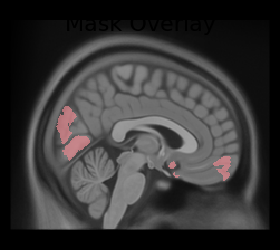

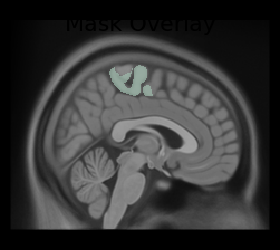

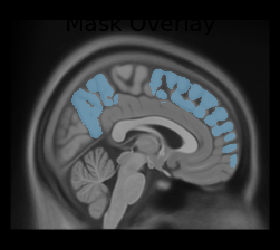

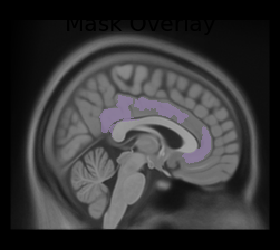

In [88]:

mni_img = load_img(mni_nifti)

for von_ec in vonecon_regions:
    # Fill in with regional mask
    filled_data = np.zeros_like(nifti_data)
    for _, row in info.iterrows():
        region_id = row['id']
        i = von_economo_map.get(von_ec, None)
        if row['von_economo_numeric'] == i:
            von_economo_value = row['von_economo_numeric']
            filled_data[nifti_data == region_id] = von_economo_value
            pass
    # Create and save new nifti
    region_name = vonecon_names[von_ec]
    region_nifti_img = nib.Nifti1Image(filled_data, affine=nifti_img.affine, header=nifti_img.header)
    output_file = os.path.join(figpath,"von_economo_" + region_name +".nii.gz")
    nib.save(region_nifti_img, output_file)
    
    # Plotting:
    # Set color scheme
    overlay_color = vonecon_palette[von_ec]
    custom_cmap = ListedColormap([overlay_color])
    roi_display = plotting.plot_roi(
        region_nifti_img,
        bg_img=mni_img,
        #title="Mask Overlay",
        display_mode="x",
        cut_coords=[2], #(2, 0, 0),
        cmap=custom_cmap,
        draw_cross=False,
        annotate = False
    )
    roi_display.title = None  # Remove the title managed by nilearn
    plt.gcf().suptitle("Mask Overlay", fontsize=16)  # Add a clean custom title

    plotting.show()



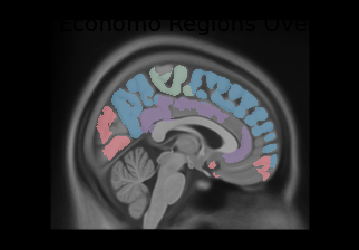

In [90]:
# Initialize a combined mask for all regions
combined_filled_data = np.zeros_like(nifti_data)

# Create a color map for all regions
all_colors = [vonecon_palette[region] for region in vonecon_regions]
custom_cmap = ListedColormap(all_colors)

# Loop through each Von Economo region
for von_ec in vonecon_regions:
    for _, row in info.iterrows():
        region_id = row['id']
        i = von_economo_map.get(von_ec, None)
        if row['von_economo_numeric'] == i:
            von_economo_value = vonecon_regions.index(von_ec) + 1  # Assign a unique index to each region
            combined_filled_data[nifti_data == region_id] = von_economo_value

# Create a combined NIfTI image for all regions
combined_nifti_img = nib.Nifti1Image(combined_filled_data, affine=nifti_img.affine, header=nifti_img.header)

# Save the combined NIfTI image
output_file = os.path.join(figpath, "von_economo_combined.nii.gz")
nib.save(combined_nifti_img, output_file)

# Plot the combined image
roi_display = plotting.plot_roi(
    combined_nifti_img,
    bg_img=mni_img,
    display_mode="x",
    cut_coords=[2], #(2, 0, 0),
    cmap=custom_cmap,
    draw_cross=False,
    annotate = False
)

# Add a title
plt.gcf().suptitle("Von Economo Regions Overlay", fontsize=16)

# Show the plot
plotting.show()